# Machine Learning Backtesting Pipeline (TensorFlow & MLflow)
This notebook implements an Expanding Window Time-Series Split, Random Forest (with GridSearchCV), Deep Neural Network (TensorFlow/Keras + KerasTuner), and Decile Sorting Backtesting.
All model training and hyperparameter searches are tracked using MLflow.


In [1]:
import IPython.core.pylabtools
import IPython.core.pylabtools
import os
import sys
import pandas as pd
import numpy as np
import datetime
import matplotlib.pyplot as plt
import mlflow
import keras_tuner as kt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from scipy.stats import spearmanr

# Ask TensorFlow to list all available physical GPUs
gpu_devices = tf.config.list_physical_devices('GPU')

if gpu_devices:
    print(f"✅ M3 Pro GPU ACTIVATED! Found: {gpu_devices}")
    # Optional: Set memory growth to prevent TF from hoarding all unified memory
    tf.config.experimental.set_memory_growth(gpu_devices[0], True)
else:
    print("❌ GPU not found. TensorFlow is falling back to the CPU.")

✅ M3 Pro GPU ACTIVATED! Found: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 1. Setup & Data Loading (with MLflow)

In [2]:
# Fix random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Spark setup
from dotenv import load_dotenv
os.chdir(os.path.abspath(os.path.join(os.getcwd(), '../../')))
sys.path.append(os.getcwd())

from src.common.setup_spark import create_spark_session
from config.config_spark import Paths

# MLflow Setup
mlflow.set_tracking_uri("sqlite:///mlflow.db") # Local SQLite database for tracking
experiment_name = "SP500_Momentum_Backtest"
mlflow.set_experiment(experiment_name)
print(f"MLflow Experiment set to: {experiment_name}")

spark = create_spark_session()
print("Spark Session created.")

# Load Data
df_gold = spark.read.format("delta").load(Paths.SP500_MOMENTUM_VALUE_PROFITABLE_TREND_WEEKLY_GOLD)
df_gold.createOrReplaceTempView("gold_prices")

df = df_gold.toPandas()

df['date'] = pd.to_datetime(df['date'])
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['week'] = df['date'].dt.weekday

#df = df[df['bull_market']==1]

print(f"Data loaded: {df.shape}")
print(f"Years: {df['year'].unique().min()}")


2026-03-11 10:58:48.516 | INFO     | src.common.setup_spark:create_spark_session:19 - 🛠️ Configurant Spark avec le connecteur GCS : https://repo1.maven.org/maven2/com/google/cloud/bigdataoss/gcs-connector/hadoop3-2.2.6/gcs-connector-hadoop3-2.2.6-shaded.jar


MLflow Experiment set to: SP500_Momentum_Backtest


26/03/11 10:58:49 WARN Utils: Your hostname, MacBook-Pro-5.local resolves to a loopback address: 127.0.0.1; using 192.168.1.1 instead (on interface en0)
26/03/11 10:58:49 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Ivy Default Cache set to: /Users/forget/.ivy2/cache
The jars for the packages stored in: /Users/forget/.ivy2/jars
io.delta#delta-spark_2.12 added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-f1072ed1-d8c5-4791-9c65-6d99ebfedf81;1.0
	confs: [default]
	found io.delta#delta-spark_2.12;3.2.1 in central
	found io.delta#delta-storage;3.2.1 in central
	found org.antlr#antlr4-runtime;4.9.3 in central
:: resolution report :: resolve 65ms :: artifacts dl 3ms
	:: modules in use:
	io.delta#delta-spark_2.12;3.2.1 from central in [default]
	io.delta#delta-storage;3.2.1 from central in [default]
	org.antlr#antlr4-runtime;4.9.3 from central in [default]
	---------------------------------------------------------------------
	|   

:: loading settings :: url = jar:file:/opt/homebrew/Caskroom/miniforge/base/envs/ml-prod-v2/lib/python3.10/site-packages/pyspark/jars/ivy-2.5.1.jar!/org/apache/ivy/core/settings/ivysettings.xml


26/03/11 10:58:49 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
2026-03-11 10:58:51.474 | SUCCESS  | src.common.setup_spark:create_spark_session:38 - ✅ Spark Session 'SparkApp' créée avec succès ! (Version: 3.5.3)


Spark Session created.


Data loaded: (692800, 131)
Years: 1985


In [3]:
df.describe()

,date,adjClose,volume,market_return,risk_free_rate,retvol,maxret,ill,beta,mom1w,...,cashConversionCycle,freeCashFlowToEquity,freeCashFlowToFirm,tangibleAssetValue,netCurrentAssetValue,bull_market,bear_market,year,month,week
count,692800,692800.000000,6.928000e+05,692800.000000,692800.000000,692800.000000,692800.000000,692800.000000,692800.000000,692800.000000,...,6.928000e+05,6.928000e+05,6.928000e+05,6.928000e+05,6.928000e+05,692800.000000,692800.000000,692800.000000,692800.000000,692800.000000
mean,2010-09-12 21:18:35.418013440,67.421128,7.777453e+06,0.000427,0.000088,-0.001038,-0.001119,-0.000535,0.000394,-0.000177,...,2.601800e+00,-1.772471e+10,7.999667e+08,5.729299e+09,-3.443595e+10,0.780401,0.219599,2010.196172,6.561142,3.963318
min,1985-09-06 00:00:00,0.004101,2.000000e+00,-0.088068,0.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,-6.085191e+05,-4.201628e+12,-2.851201e+13,-2.657730e+11,-4.229289e+12,0.000000,0.000000,1985.000000,1.000000,0.000000
25%,2003-02-21 00:00:00,11.980000,9.567228e+05,-0.004305,0.000004,-0.501075,-0.501155,-0.503106,-0.500000,-0.500975,...,3.324904e+00,-7.247000e+09,-7.107290e+06,0.000000e+00,-1.381200e+10,1.000000,0.000000,2003.000000,4.000000,4.000000
50%,2012-06-22 00:00:00,28.990000,2.195348e+06,0.000874,0.000063,0.000000,0.000000,0.000000,0.000000,0.000000,...,4.351178e+01,-2.042000e+09,1.240798e+08,1.654000e+09,-3.420000e+09,1.000000,0.000000,2012.000000,7.000000,4.000000
75%,2019-08-31 18:00:00,66.760000,5.099041e+06,0.005707,0.000174,0.498956,0.500000,0.502304,0.500000,0.500000,...,9.424215e+01,-1.034160e+08,5.679884e+08,6.046500e+09,-9.173500e+07,1.000000,0.000000,2019.000000,10.000000,4.000000
max,2026-02-20 00:00:00,9924.400000,9.276606e+09,0.092871,0.000328,1.000000,1.000000,1.000000,1.000000,1.000000,...,3.646007e+06,4.842830e+11,2.853340e+13,3.229622e+12,3.164338e+13,1.000000,1.000000,2026.000000,12.000000,4.000000
std,NaN,191.216925,4.625319e+07,0.010900,0.000087,0.578117,0.579065,0.579858,0.578166,0.578542,...,1.655249e+04,1.548944e+11,3.140788e+11,2.870217e+10,3.680085e+11,0.413975,0.413975,10.679603,3.463799,0.208719


### Calculate Target Variable: 1-Month Ahead Expected Excess Return

In [4]:
import pandas as pd
import numpy as np

def create_advanced_target(df, forward_weeks=4, top_n=10, pourcentage_target=0.05):
    """
    Crée une cible de classification binaire (0 ou 1).
    Cible = 1 SI l'action est dans le Top N de la semaine 
              ET SI son rendement sur N semaines est strictement supérieur au seuil.
    """
    df = df.copy()
    
    # --- 0. S'assurer des formats et du tri initial ---
    df['date'] = pd.to_datetime(df['date'])
    df = df.sort_values(by=['symbol', 'date'])
    
    # --- 1. Calculer le rendement futur brut ---
    df['return_forward'] = df.groupby('symbol')['adjClose'].shift(-forward_weeks) / df['adjClose'] - 1
    
    # Sécurité : On supprime les lignes à la fin du dataset qui n'ont pas encore de futur
    df = df.dropna(subset=['return_forward']).copy()
    
    # --- 2. Classement Transversal (Cross-Sectional Ranking) ---
    # Pour chaque semaine, on classe les actions. ascending=False met le plus gros rendement en rang 1
    df['rank_cross_sectional'] = df.groupby('date')['return_forward'].rank(method='first', ascending=False)
    
    # --- 3. Création de la cible (Classification) ---
    cond_top_n = df['rank_cross_sectional'] <= top_n
    cond_absolute_return = df['return_forward'] > pourcentage_target
    
    # L'action reçoit un 1 uniquement si elle remplit les DEUX conditions
    df['target_y'] = (cond_top_n & cond_absolute_return).astype(int)
    
    # --- 4. Nettoyage du dataset final ---
    df = df.drop(columns=['rank_cross_sectional'])
    # Optionnel : tu peux supprimer le rendement brut si tu ne veux fournir que 'target_y' à ton modèle
    df = df.drop(columns=['return_forward'])
    
    return df

# Exécution de la fonction (Exemple : Top 10 des actions faisant au moins +5% en 4 semaines)
df = create_advanced_target(df, forward_weeks=26, top_n=50, pourcentage_target=0.15)


## 4. Algorithm Model Architectures

In [5]:

colonne_list = df.columns.tolist()
colonnes_texte = df.select_dtypes(exclude=['number']).columns.tolist()
colonnes_biais = ['date', 'volume', 'adjClose','symbol', 'workingCapital', 'investedCapital', 'grahamNumber', 'target_y', 'adjClose_GSPC', 'year']
features = set(colonne_list) - set(colonnes_texte) - set(colonnes_biais)
features = list(features)
print("features :", features)
print(len(features))

features : ['debtToCapitalRatio', 'evToEBITDA', 'operatingCashFlowPerShare', 'returnOnCapitalEmployed', 'mom1m', 'evToOperatingCashFlow', 'dividendYield', 'tangibleBookValuePerShare', 'returnOnInvestedCapital', 'averageInventory', 'mom36m', 'effectiveTaxRate', 'longTermDebtToCapitalRatio', 'quickRatio', 'priceToFreeCashFlowRatio', 'mom12m', 'dividendPaidAndCapexCoverageRatio', 'evToSales', 'shortTermOperatingCashFlowCoverageRatio', 'earningsYield', 'capexToOperatingCashFlow', 'high52', 'maxret', 'dist_ma25', 'solvencyRatio', 'cashConversionCycle', 'dist_ma4', 'ebitdaMargin', 'shareholdersEquityPerShare', 'capexToRevenue', 'dist_ma50', 'market_return', 'priceToEarningsGrowthRatio', 'ill', 'returnOnEquity', 'beta', 'returnOnTangibleAssets', 'returnOnAssets', 'bookValuePerShare', 'enterpriseValue', 'netIncomePerShare', 'operatingCashFlowRatio', 'averageReceivables', 'debtToAssetsRatio', 'interestBurden', 'chmom', 'revenuePerShare', 'enterpriseValueMultiple', 'tangibleAssetValue', 'bottomL

In [6]:
# Define features. Exclude identifiers and target.
print(df.isna().sum())

# Ensure no NaNs in features

df = df.dropna(subset=features)
df = df.reset_index(drop=True)

print(f"Data after target creation: {df.shape}")
print(f"Years: {df['year'].unique().min()}")

symbol           0
date             0
adjClose         0
volume           0
market_return    0
                ..
bear_market      0
year             0
month            0
week             0
target_y         0
Length: 132, dtype: int64
Data after target creation: (673698, 132)
Years: 1985


## 2. Expanding Window Time-Series Split

In [7]:

def get_classic_train_val_test_splits(df, val_years, test_years):
    """    
    Yields a single, classic chronological split (Train -> Val -> Test).
    It splits based on the last N years of your dataset.
    """
    years = sorted(df['year'].unique())
    
    print(f"Total years in dataset: {years[0]} to {years[-1]}")
    
    # Calculate the cutoff years from the end of the dataset
    test_start_year = years[-test_years]
    val_start_year = years[-(test_years + val_years)]
    
    print(f"Train ends before: {val_start_year}")
    print(f"Validation: {val_start_year} to {test_start_year - 1}")
    print(f"Test: {test_start_year} to {years[-1]}")
    
    # 1. Train: Everything before the validation period
    train_idx = df[df['year'] < val_start_year].index
    
    # 2. Validation: The specific validation years
    val_idx = df[(df['year'] >= val_start_year) & (df['year'] < test_start_year)].index
    
    # 3. Test: The final years
    test_idx = df[df['year'] >= test_start_year].index
    
    # Create a label for the test period so your MLflow charts name it correctly
    test_label = test_start_year
    
    # Return as a single-element list so your existing 'for' loop still works perfectly!
    return [(train_idx, val_idx, test_idx, test_label)]

# --- Testing the function ---
splits = get_classic_train_val_test_splits(df, val_years=5, test_years=10)

print(f"\nTotal static splits: {len(splits)}")
for i, (tr, val, ts, yr) in enumerate(splits):
    print(f"Split {i+1} | Test Period: {yr} | Train: {len(tr)} rows | Val: {len(val)} rows | Test: {len(ts)} rows")


Total years in dataset: 1985 to 2025
Train ends before: 2011
Validation: 2011 to 2015
Test: 2016 to 2025

Total static splits: 1
Split 1 | Test Period: 2016 | Train: 313381 rows | Val: 111088 rows | Test: 249229 rows


In [8]:
"""
def get_train_val_test_splits(df, initial_train_years=20, val_years=3, test_years=1):
    
    #Yields train, val, test indices for an expanding window split.
    
    years = sorted(df['year'].unique())

    start_year = years[0]
    
    current_test_year = start_year + initial_train_years + val_years
    print(current_test_year)
    
    splits = []
    
    while current_test_year <= years[-1]:
        train_end = current_test_year - val_years - 1
        val_end = current_test_year - 1
        
        train_idx = df[df['year'] <= train_end].index
        val_idx = df[(df['year'] > train_end) & (df['year'] <= val_end)].index
        test_idx = df[df['year'] == current_test_year].index
        
        splits.append((train_idx, val_idx, test_idx, current_test_year))
        current_test_year += 1
        
    return splits

splits = get_train_val_test_splits(df)
print(f"Total expanding window splits: {len(splits)}")
for i, (tr, val, ts, yr) in enumerate(splits):
    print(f"Split {i+1} | Test Year: {yr} | Train: {len(tr)} | Val: {len(val)} | Test: {len(ts)}")
"""

'\ndef get_train_val_test_splits(df, initial_train_years=20, val_years=3, test_years=1):\n    \n    #Yields train, val, test indices for an expanding window split.\n    \n    years = sorted(df[\'year\'].unique())\n\n    start_year = years[0]\n    \n    current_test_year = start_year + initial_train_years + val_years\n    print(current_test_year)\n    \n    splits = []\n    \n    while current_test_year <= years[-1]:\n        train_end = current_test_year - val_years - 1\n        val_end = current_test_year - 1\n        \n        train_idx = df[df[\'year\'] <= train_end].index\n        val_idx = df[(df[\'year\'] > train_end) & (df[\'year\'] <= val_end)].index\n        test_idx = df[df[\'year\'] == current_test_year].index\n        \n        splits.append((train_idx, val_idx, test_idx, current_test_year))\n        current_test_year += 1\n        \n    return splits\n\nsplits = get_train_val_test_splits(df)\nprint(f"Total expanding window splits: {len(splits)}")\nfor i, (tr, val, ts, yr) 

## Reduction Features

Features à supprimer (corrélation > 0.8) :
{'assetTurnover', 'forwardPriceToEarningsGrowthRatio', 'salesGeneralAndAdministrativeToRevenue', 'operatingCycle', 'inventoryTurnover', 'debtToEquityRatio', 'continuousOperationsProfitMargin', 'evToFreeCashFlow', 'evToOperatingCashFlow', 'currentRatio', 'priceToSalesRatio', 'bull_market', 'netDebtToEBITDA', 'freeCashFlowToEquity', 'freeCashFlowOperatingCashFlowRatio', 'operatingCashFlowSalesRatio', 'priceToFreeCashFlowRatio', 'priceToOperatingCashFlowRatio', 'daysOfInventoryOutstanding', 'ebitMargin', 'mom6m', 'dividendYieldPercentage', 'pretaxProfitMargin', 'solvencyRatio', 'debtServiceCoverageRatio', 'dist_ma50', 'netIncomePerEBT', 'returnOnTangibleAssets', 'returnOnAssets', 'priceToEarningsRatio', 'dist_ma12', 'operatingProfitMargin', 'priceToFairValue', 'mom3m', 'debtToAssetsRatio', 'enterpriseValueMultiple', 'netProfitMargin', 'bottomLineProfitMargin', 'taxBurden'}


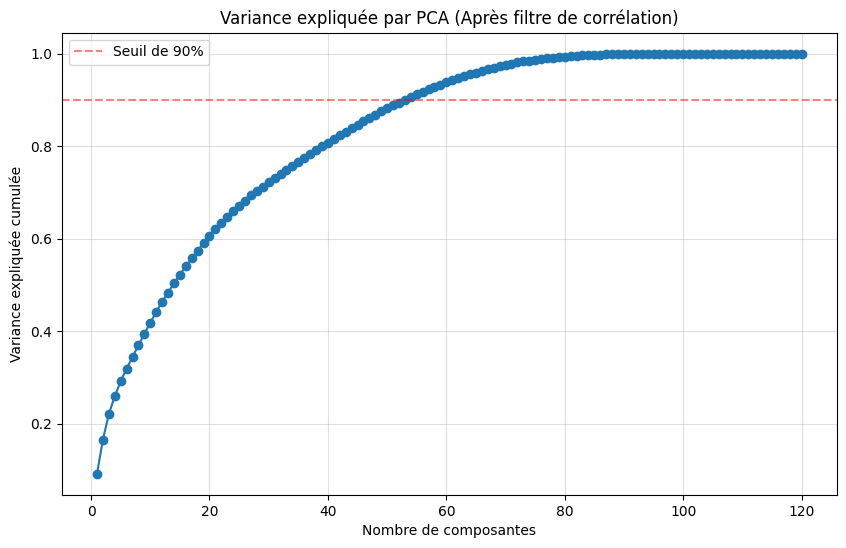

In [9]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt

# On s'assure qu'on a bien des splits
if len(splits) > 0:
    # 1. Récupération de X_train (en format DataFrame)
    train_idx, val_idx, test_idx, test_year = splits[0]
    X_train_df = df.loc[train_idx, features] 
    
    # ---------------------------------------------------------
    # 2. FILTRE DES CORRÉLATIONS
    # ---------------------------------------------------------
    threshold = 0.8
    col_corr = set()  # Ensemble des colonnes à supprimer
    corr_matrix = X_train_df.corr()

    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i, j]) > threshold:
                colname = corr_matrix.columns[i]
                col_corr.add(colname)

    print(f"Features à supprimer (corrélation > {threshold}) :")
    print(col_corr)

    # DataFrame réduit
    #df_reduced = X_train_df.drop(columns=col_corr)
    #print(f"Dimensions avant PCA : {df_reduced.shape}")
    
    # ---------------------------------------------------------
    # 3. SCALING & PCA (Sur le DataFrame réduit !)
    # ---------------------------------------------------------
    # Centrage et Réduction
    scaler = StandardScaler()
    X_train_scale = scaler.fit_transform(X_train_df) 
    
    # Entraînement de la PCA
    pca = PCA()
    pca.fit(X_train_scale)

    # Calcul de la variance expliquée
    explained_var = pca.explained_variance_ratio_
    cumulative_var = np.cumsum(explained_var)

    # 4. Affichage du graphique
    plt.figure(figsize=(10, 6))
    # range(1, ...) permet d'avoir l'axe X qui commence à 1 composante (et pas 0)
    plt.plot(range(1, len(cumulative_var) + 1), cumulative_var, marker='o')
    plt.axhline(y=0.90, color='r', linestyle='--', alpha=0.5, label='Seuil de 90%') # Ligne visuelle
    plt.xlabel("Nombre de composantes")
    plt.ylabel("Variance expliquée cumulée")
    plt.title("Variance expliquée par PCA (Après filtre de corrélation)")
    plt.legend()
    plt.grid(True, alpha=0.4)
    plt.show()
    
else:
    print("Pas assez de données pour le split.")

## 3. Evaluation Metrics ($R^2_{OOS}$)

In [10]:
def calculate_mcc(y_true, y_pred):
    """
    Calcule le Matthews Correlation Coefficient (MCC) pour des classes déséquilibrées.
    
    y_true : array ou liste des vraies étiquettes (0 ou 1)
    y_pred : array ou liste des prédictions de l'IA (0 ou 1)
    """
    # Conversion en arrays numpy pour faciliter les calculs vectoriels
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    # 1. Comptage physique de la matrice de confusion
    TP = np.sum((y_true == 1) & (y_pred == 1))
    TN = np.sum((y_true == 0) & (y_pred == 0))
    FP = np.sum((y_true == 0) & (y_pred == 1))
    FN = np.sum((y_true == 1) & (y_pred == 0))
    
    # 2. Calcul du Numérateur (La différence croisée)
    numerator = (TP * TN) - (FP * FN)
    
    # 3. Calcul du Dénominateur (Produit des marges)
    # On ajoute un float( ) pour éviter un dépassement de capacité (overflow)
    denominator = np.sqrt(float((TP + FP) * (TP + FN) * (TN + FP) * (TN + FN)))
    
    # 4. Sécurité : Si le dénominateur est 0, le MCC est défini comme 0
    if denominator == 0:
        return 0.0
        
    return numerator / denominator


### Deep Neural Network (KerasTuner + MLflow Autolog + Ensembling)

In [11]:
def build_model(hp, input_dim):
    """KerasTuner model building function"""
    model = keras.Sequential()
    model.add(layers.Input(shape=(input_dim,)))
    
    # Tune the number of units in the first Dense layer
    hp_units1 = hp.Int('units_1', min_value=16, max_value=64, step=16)
    model.add(layers.Dense(units=hp_units1, kernel_regularizer=regularizers.l1(1e-5)))
    model.add(layers.BatchNormalization())
    model.add(layers.ReLU())
    
    # Tune the number of units in the second Dense layer
    hp_units2 = hp.Int('units_2', min_value=8, max_value=32, step=8)
    model.add(layers.Dense(units=hp_units2, kernel_regularizer=regularizers.l1(1e-5)))
    model.add(layers.BatchNormalization())
    model.add(layers.ReLU())
    
    # Third hidden layer (fixed small)
    hp_units3 = hp.Int('units_3', min_value=4, max_value=8, step=2)
    model.add(layers.Dense(units=hp_units3, kernel_regularizer=regularizers.l1(1e-5)))
    model.add(layers.BatchNormalization())
    model.add(layers.ReLU())
    
    # Output layer
    model.add(layers.Dense(1, activation='sigmoid'))
    
    # Tune the learning rate for the optimizer
    hp_learning_rate = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])
    
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=hp_learning_rate),
                  loss='binary_crossentropy',
                  metrics=[
                  'accuracy', 
                      keras.metrics.AUC(name='auc'), # 👈 Crucial pour les données déséquilibrées
                      keras.metrics.Precision(name='precision') # Très utile pour ton Stock Picking
                  ])
    return model

def train_dnn_ensemble(X_train, y_train, X_val, y_val, scaler, num_models=5, epochs=100, patience=5):
    mlflow.tensorflow.autolog(disable=True) 
    
    X_train_scaled = scaler.transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    input_dim = X_train_scaled.shape[1]
    
    # ==========================================
    # 🚀 THE MLOPS FIX: tf.data PIPELINE
    # ==========================================
    batch_size = 32768 # You can increase this to 512 or 1024 if VRAM allows
    
    # 1. Train Dataset: Shuffle, Batch, Cache, and Prefetch
    train_dataset = tf.data.Dataset.from_tensor_slices((X_train_scaled, y_train.values))
    train_dataset = train_dataset.shuffle(buffer_size=len(X_train_scaled)) \
                                 .batch(batch_size) \
                                 .cache() \
                                 .prefetch(tf.data.AUTOTUNE)
                                 
    # 2. Validation Dataset: Batch, Cache, and Prefetch (No need to shuffle val data)
    val_dataset = tf.data.Dataset.from_tensor_slices((X_val_scaled, y_val.values))
    val_dataset = val_dataset.batch(batch_size) \
                             .cache() \
                             .prefetch(tf.data.AUTOTUNE)
    # ==========================================

    print("Starting KerasTuner RandomSearch...")
    with tf.device('/CPU:0'):
        tuner = kt.RandomSearch(
            lambda hp: build_model(hp, input_dim),
            objective='val_loss',
            max_trials=5,     
            directory='keras_tuner_dir',
            project_name='momentum_dnn',
            overwrite=True
        )
    
        early_stopping = keras.callbacks.EarlyStopping(monitor='val_loss', patience=patience, restore_best_weights=True)
        
        # Pass the datasets instead of raw arrays. Drop the 'batch_size' arg since the dataset handles it.
        tuner.search(train_dataset, epochs=30, validation_data=val_dataset, callbacks=[early_stopping], verbose=0)
        best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
        print(f"Best HPs found: Layer1: {best_hps.get('units_1')}, Layer2: {best_hps.get('units_2')}, LR: {best_hps.get('learning_rate')}")
    
    models = []
    mlflow.tensorflow.autolog() 
    
    for i in range(num_models):
        with mlflow.start_run(run_name=f"DNN_Ensemble_Member_{i+1}", nested=True):
            mlflow.log_params(best_hps.values)
            tf.random.set_seed(42 + i)
            
            model = tuner.hypermodel.build(best_hps)
            
            # Use the pre-built tf.data pipeline for blazing fast training
            history = model.fit(
                train_dataset,
                epochs=epochs,
                validation_data=val_dataset,
                callbacks=[early_stopping],
                verbose=0
            )
            val_loss = min(history.history['val_loss'])
            print(f"Trained DNN component {i+1}/{num_models} - Best Val Loss: {val_loss:.6f}")
            models.append(model)
        
    return models

def predict_dnn_ensemble(models, scaler, X_test):
    X_test_scaled = scaler.transform(X_test)
    
    # Create a fast prediction pipeline
    test_dataset = tf.data.Dataset.from_tensor_slices(X_test_scaled)
    test_dataset = test_dataset.batch(32768).cache().prefetch(tf.data.AUTOTUNE)
    
    preds = []
    for model in models:
        # Pass the dataset to predict
        pred = model.predict(test_dataset, verbose=0).flatten()
        preds.append(pred)
        
    return np.mean(preds, axis=0)


## 5. Backtesting Portfolio Construction (Decile Sorting)

In [12]:
import pandas as pd
import numpy as np

def backtest_portfolio(test_df, predictions_col, transaction_cost=0.001, top_n=10):
    """
    Simulates a Long-Only portfolio with dynamic transaction costs.
    Invests strictly in the Top N performing stocks based on predictions_col.
    """
    results = []
    
    # CRITICAL FIX 1: Sort dataframe before shift(-1)
    test_df = test_df.copy()
    test_df['date'] = pd.to_datetime(test_df['date'])
    test_df = test_df.sort_values(by=['symbol', 'date'])
    
    # Calculate future return
    test_df['return+1'] = test_df.groupby('symbol')['adjClose'].shift(-1) / test_df['adjClose'] - 1
    
    # 🛠️ CORRECTION 1 : On supprime la dernière ligne vide pour éviter les NaN
    test_df = test_df.dropna(subset=['return+1'])
    
    prev_long_symbols = set()

    for date, week_data in test_df.groupby('date'):
        if len(week_data) < top_n: 
            continue
            
        week_data = week_data.copy()
        
        # --- 1. BENCHMARK CALCULATION ---
        if 'dollar_volume' not in week_data.columns:
            week_data['dollar_volume'] = week_data['volume'] * week_data['adjClose']
            
        universe_weights = week_data['dollar_volume'] / week_data['dollar_volume'].sum()
        benchmark_return = np.sum(universe_weights * week_data['return+1'])
        
        # --- 2. PORTFOLIO TOP N (LONG ONLY) ---
        try:
            # 🛠️ CORRECTION 2 : Filtrage propre sans détruire les types de données
            valid_stocks = week_data[week_data[predictions_col] > 0.5].copy()
            
            # On trie les actions survivantes
            valid_stocks = valid_stocks.sort_values(by=predictions_col, ascending=False)
            
            # On prend strictement le Top N
            long_portfolio = valid_stocks.head(top_n)
            
            curr_long_symbols = set(long_portfolio['symbol'])
            num_l = len(curr_long_symbols)
            
            if num_l > 0:
                # 🛠️ CORRECTION 3 : Gestion correcte du Cash (On divise par top_n)
                gross_portfolio_return = long_portfolio['return+1'].sum() / top_n
                
                # --- 3. DYNAMIC TRANSACTION COSTS (TURNOVER) ---
                new_longs = curr_long_symbols - prev_long_symbols
                
                # Turnover basé sur la taille totale du portefeuille
                turnover_long = len(new_longs) / top_n 
                
                cost_long = turnover_long * transaction_cost * 2
                net_portfolio_return = gross_portfolio_return - cost_long
                
                prev_long_symbols = curr_long_symbols
            else:
                # Si aucune action ne passe le filtre > 0.5, on passe 100% en Cash
                gross_portfolio_return, net_portfolio_return, turnover_long, num_l = 0, 0, 0, 0
                prev_long_symbols = set()
                
        except Exception as e:
            # 🛠️ CORRECTION 4 : On affiche l'erreur au lieu de la cacher !
            print(f"❌ Erreur à la date {date} : {e}")
            gross_portfolio_return, net_portfolio_return, turnover_long, num_l = 0, 0, 0, 0
            prev_long_symbols = set()
            
        # Append results for this week
        results.append({
            'date': date,
            'gross_return': gross_portfolio_return,
            'portfolio_return': net_portfolio_return,
            'benchmark_return': benchmark_return,
            'turnover_pct': turnover_long,
            'num_long': num_l
        })
            
    bt_df = pd.DataFrame(results)

    # --- METRICS CALCULATION ---
    if bt_df.empty:
        return bt_df, {}
        
    bt_df['date'] = pd.to_datetime(bt_df['date'])
    bt_df = bt_df.dropna(subset=['portfolio_return'])
    
    bt_df['cum_return'] = (1 + bt_df['portfolio_return']).cumprod()
    bt_df['cum_benchmark'] = (1 + bt_df['benchmark_return']).cumprod()
    bt_df['outperformance'] = bt_df['cum_return'] - bt_df['cum_benchmark']

    n_years = bt_df['date'].dt.year.nunique()
    
    total_ret = bt_df['cum_return'].iloc[-1] - 1
    cagr = (bt_df['cum_return'].iloc[-1]) ** (1 / max(1, n_years)) - 1
    mean_ret = bt_df['portfolio_return'].mean()
    std_ret = bt_df['portfolio_return'].std()
    sharpe = ((mean_ret / std_ret) * np.sqrt(52)) if std_ret > 0 else 0
    max_dd = ((bt_df['cum_return'] - bt_df['cum_return'].cummax()) / bt_df['cum_return'].cummax()).min()

    bench_total_ret = bt_df['cum_benchmark'].iloc[-1] - 1
    bench_cagr = (bt_df['cum_benchmark'].iloc[-1]) ** (1 / max(1, n_years)) - 1 if n_years > 0 and bt_df['cum_benchmark'].iloc[-1] > 0 else 0
    bench_mean = bt_df['benchmark_return'].mean()
    bench_std = bt_df['benchmark_return'].std()
    bench_sharpe = (bench_mean / bench_std) * np.sqrt(52) if bench_std > 0 else 0
    bench_max_dd = ((bt_df['cum_benchmark'] - bt_df['cum_benchmark'].cummax()) / bt_df['cum_benchmark'].cummax()).min()
        
    metrics = {
        'Total_Return': total_ret,
        'CAGR': cagr,
        'Sharpe_Ratio': sharpe,
        'Max_Drawdown': max_dd,
        'Bench_Total_Return': bench_total_ret,
        'Bench_CAGR': bench_cagr,
        'Bench_Sharpe': bench_sharpe,
        'Bench_Max_Drawdown': bench_max_dd
    }
    
    return bt_df, metrics

## 6. Run the Pipeline over the Expanding Window

In [13]:
if len(splits) > 0:
    print(f"🚀 Lancement du Walk-Forward Backtest sur {len(splits)} années...")
    
    all_oos_results = []

    STRATEGY_FREQ = "weekly"
    TRANS_COST = 0.001
    DNN_EPOCHS = 100
    DNN_MODELS = 5
    TARGET_FREQ = "6 mois"
    NUM_SPLITS = 1
    TOP = 50
    NOTES = "Test avec une target de 6 mois et une fréquence hebdomadaire avec 1 split. Momentum, Valorisation, Rentabilité"

    mlflow.set_experiment("Maximize_CAGR_SP500_Classification")
    
    run_name = f"Test_{STRATEGY_FREQ}_Cost{TRANS_COST}_DnnEp{DNN_EPOCHS}_DnnModels{DNN_MODELS}_Target{TARGET_FREQ}_Top{TOP}_Splits{NUM_SPLITS}_Notes{NOTES}"

    # On ouvre un seul grand Run MLflow pour tout le backtest
    with mlflow.start_run(run_name="CAGR_Forward_Backtest") as parent_run:

        mlflow.set_tag("Frequency", "Weekly")
        
        # 1. ENREGISTREMENT DES PARAMÈTRES GLOBAUX
        mlflow.log_params({
            "frequency": STRATEGY_FREQ,
            "features_count": len(features),
            "features_list": ", ".join(features),
            "transaction_cost": TRANS_COST,
            "dnn_epochs": DNN_EPOCHS,
            "dnn_num_models": DNN_MODELS,
            "target_freq": TARGET_FREQ,
            "top": TOP,
            "num_splits": NUM_SPLITS,
            "notes": NOTES
        })
        
        # 2. LA BOUCLE SUR TOUTES LES ANNÉES
        for i, (train_idx, val_idx, test_idx, test_year) in enumerate(splits):
            print(f"\n--- Traitement de l'Année de Test {test_year} ({i+1}/{len(splits)}) ---")
            
            X_train, y_train = df.loc[train_idx, features], df.loc[train_idx, 'target_y']
            X_val, y_val = df.loc[val_idx, features], df.loc[val_idx, 'target_y']
            X_test, y_test = df.loc[test_idx, features], df.loc[test_idx, 'target_y']
            
            # Setup scaler for DNN (réajusté chaque année)
            scaler = StandardScaler()
            scaler.fit(X_train)
            
            # Entraînement DNN
            print("  -> Training DNN Ensemble...")
            dnn_models = train_dnn_ensemble(X_train, y_train, X_val, y_val, scaler, num_models=DNN_MODELS, epochs=DNN_EPOCHS, patience=3)
            dnn_preds = predict_dnn_ensemble(dnn_models, scaler, X_test)
            
            # --- SUIVI ANNÉE PAR ANNÉE ---
            r2_dnn_year = float(calculate_mcc(y_test.values, dnn_preds))
            
            # On force le cast en int() pour le step !
            mlflow.log_metric("Yearly_DNN_R2_OOS", r2_dnn_year, step=int(test_year))
            
            print(f"  -> DNN R2 {test_year}: {r2_dnn_year:.4f}")
            
            # Stockage des prédictions pour cette année
            test_df_year = df.loc[test_idx].copy()
            test_df_year['dnn_pred'] = dnn_preds
            
            all_oos_results.append(test_df_year)
            
        # =========================================================
        # 3. L'ASSEMBLAGE (Le vrai Backtest Global)
        # =========================================================
        print("\n" + "="*50)
        print("🔗 Assemblage des prédictions et calcul du Backtest Global...")
        
        final_test_df = pd.concat(all_oos_results).sort_values(['symbol', 'date'])
        
        # --- SAUVEGARDE DES PRÉDICTIONS BRUTES EN ARTEFACT ---
        print("💾 Sauvegarde des prédictions brutes dans MLflow...")
        csv_path = "final_predictions.csv"
        final_test_df.to_csv(csv_path, index=False)
        mlflow.log_artifact(csv_path)
        
        # Évaluation R^2 globale sur toute la période OOS
        r2_dnn_global = calculate_mcc(final_test_df['target_y'].values, final_test_df['dnn_pred'].values)
        
        mlflow.log_metric("Global_DNN_R2_OOS", r2_dnn_global)
        
        # Passage au simulateur de portefeuille
        print("Running Backtest for DNN Strategy...")
        bt_dnn, metrics_dnn = backtest_portfolio(final_test_df, 'dnn_pred', transaction_cost=TRANS_COST, top_n=TOP)
        
        # 4. AFFICHAGE ET SAUVEGARDE FINALE
        if not bt_dnn.empty:
            
            # Sauvegarde des métriques financières dans MLflow en forçant le type float()
            mlflow.log_metrics({f"DNN_{k}": float(v) for k, v in metrics_dnn.items()})
            
            # Sauvegarde aussi le R2 global en forçant le float() (juste au cas où)
            mlflow.log_metric("Global_DNN_R2_OOS", float(r2_dnn_global))
            
            # Formatage du joli tableau pour la console
            metrics_table = pd.DataFrame({
                "Métrique": ["Total Return", "CAGR (Annualisé)", "Sharpe Ratio", "Max Drawdown"],
                "DNN Ensemble": [f"{metrics_dnn['Total_Return']*100:.2f}%", f"{metrics_dnn['CAGR']*100:.2f}%", f"{metrics_dnn['Sharpe_Ratio']:.2f}", f"{metrics_dnn['Max_Drawdown']*100:.2f}%"]
            })
            
            print("\n" + "="*55)
            print("📊 TABLEAU DES PERFORMANCES FINALES (AVEC FRAIS)")
            print("="*55)
            print(metrics_table.to_string(index=False))
            print("="*55 + "\n")
            
            # Sauvegarde du tableau en format texte brut dans MLflow
            with open("performance_metrics.txt", "w") as f:
                f.write(metrics_table.to_string(index=False))
            mlflow.log_artifact("performance_metrics.txt")
            
        else:
            print("Backtest yielded empty results (perhaps not enough data to form deciles).")
          
else:
    print("Not enough data to form a split. Check your timeframe.")


🚀 Lancement du Walk-Forward Backtest sur 1 années...

--- Traitement de l'Année de Test 2016 (1/1) ---
  -> Training DNN Ensemble...


2026-03-11 10:59:30.732216: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3 Pro
2026-03-11 10:59:30.732247: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 36.00 GB
2026-03-11 10:59:30.732255: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 14.04 GB
I0000 00:00:1773223170.732267  162955 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1773223170.732295  162955 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Starting KerasTuner RandomSearch...
Best HPs found: Layer1: 16, Layer2: 16, LR: 0.001


2026-03-11 10:59:47.524868: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-03-11 10:59:47.552334: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


2026-03-11 10:59:47.959880: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


...

Trained DNN component 4/5 - Best Val Loss: 0.691350


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step


2026/03/11 11:00:39 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/11 11:00:45 WARNING mlflow.utils.autologging_utils: Encountered unexpected error during tensorflow autologging: 0.6127644777297974 is not in list


Trained DNN component 5/5 - Best Val Loss: 0.650672


  -> DNN R2 2016: 0.0000

🔗 Assemblage des prédictions et calcul du Backtest Global...
💾 Sauvegarde des prédictions brutes dans MLflow...
Running Backtest for DNN Strategy...

📊 TABLEAU DES PERFORMANCES FINALES (AVEC FRAIS)
        Métrique DNN Ensemble
    Total Return      103.73%
CAGR (Annualisé)        7.38%
    Sharpe Ratio         0.67
    Max Drawdown      -26.40%



## 7. Visualisation results

Running Backtest for DNN Strategy...

📊 TABLEAU DES PERFORMANCES FINALES (HEBDOMADAIRE - AVEC FRAIS 0.1%)
        Métrique DNN Ensemble
    Total Return      353.30%
CAGR (Annualisé)       16.32%
    Sharpe Ratio         0.72
    Max Drawdown      -51.95%



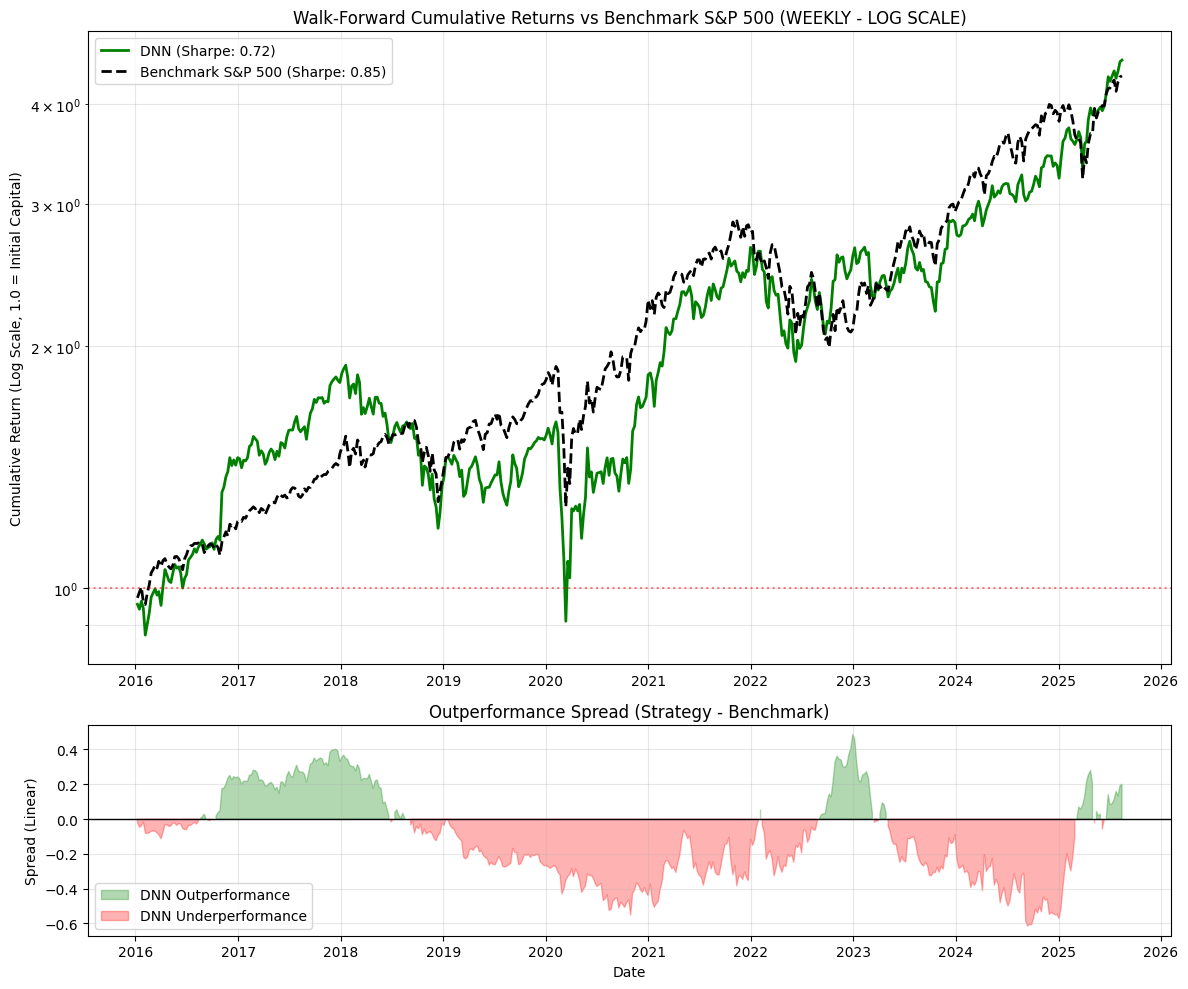

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

print("Running Backtest for DNN Strategy...")
# On garde ton paramétrage (transaction_cost=0.001, decile=55)
bt_dnn, metrics_dnn = backtest_portfolio(final_test_df, 'dnn_pred', transaction_cost=0.001, top_n=7)

if not bt_dnn.empty:
    # 1. TABLEAU DES PERFORMANCES (DNN UNIQUEMENT)
    metrics_table = pd.DataFrame({
        "Métrique": ["Total Return", "CAGR (Annualisé)", "Sharpe Ratio", "Max Drawdown"],
        "DNN Ensemble": [f"{metrics_dnn['Total_Return']*100:.2f}%", f"{metrics_dnn['CAGR']*100:.2f}%", f"{metrics_dnn['Sharpe_Ratio']:.2f}", f"{metrics_dnn['Max_Drawdown']*100:.2f}%"]
    })
    
    print("\n" + "="*55)
    print("📊 TABLEAU DES PERFORMANCES FINALES (HEBDOMADAIRE - AVEC FRAIS 0.1%)")
    print("="*55)
    print(metrics_table.to_string(index=False))
    print("="*55 + "\n")

    # 2. GRAPHIQUES (DNN vs BENCHMARK)
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), gridspec_kw={'height_ratios': [3, 1]})
    
    # --- Axe 1 : Rendements cumulés (Échelle Logarithmique) ---
    ax1.plot(bt_dnn['date'], bt_dnn['cum_return'], label=f"DNN (Sharpe: {metrics_dnn['Sharpe_Ratio']:.2f})", color='green', linewidth=2)
    
    # On utilise maintenant metrics_dnn pour récupérer le Sharpe du Benchmark
    ax1.plot(bt_dnn['date'], bt_dnn['cum_benchmark'], label=f"Benchmark S&P 500 (Sharpe: {metrics_dnn['Bench_Sharpe']:.2f})", color='black', linestyle='--', linewidth=2)
    
    ax1.axhline(y=1.0, color='red', linestyle=':', alpha=0.5)
    ax1.set_yscale('log')
    ax1.set_title('Walk-Forward Cumulative Returns vs Benchmark S&P 500 (WEEKLY - LOG SCALE)')
    ax1.set_ylabel('Cumulative Return (Log Scale, 1.0 = Initial Capital)')
    ax1.legend()
    ax1.grid(True, which="both", alpha=0.3)
    
    # --- Axe 2 : Spread d'Outperformance (DNN uniquement) ---
    ax2.fill_between(bt_dnn['date'], bt_dnn['outperformance'], 0, where=(bt_dnn['outperformance'] >= 0), color='green', alpha=0.3, label='DNN Outperformance')
    ax2.fill_between(bt_dnn['date'], bt_dnn['outperformance'], 0, where=(bt_dnn['outperformance'] < 0), color='red', alpha=0.3, label='DNN Underperformance')
    
    ax2.axhline(y=0.0, color='black', linewidth=1)
    ax2.set_title('Outperformance Spread (Strategy - Benchmark)')
    ax2.set_xlabel('Date')
    ax2.set_ylabel('Spread (Linear)')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()

    # 3. SAUVEGARDE MLFLOW
    plot_path = "global_cumulative_returns_vs_benchmark.png"
    plt.savefig(plot_path)
    mlflow.log_artifact(plot_path)
    
    plt.show()
    
else:
    print("Le backtest du DNN est vide (peut-être pas assez de données pour former les déciles).")

In [15]:
final_test_df[final_test_df['dnn_pred']>0.5][['symbol', 'date', 'target_y', 'dnn_pred']].sort_values(by='date', ascending=False)

,symbol,date,target_y,dnn_pred
291262,HAS,2025-08-22,0,0.502559
283298,GS,2025-08-22,0,0.633986
273799,GM,2025-08-22,1,0.513865
370941,LEN,2025-08-22,0,0.510542
64551,AXON,2025-08-22,0,0.510967
...,...,...,...,...
282796,GS,2016-01-08,0,0.700972
197890,DVN,2016-01-08,1,0.522518
90956,BK,2016-01-08,0,0.579365
146504,COOP,2016-01-08,0,0.520873


In [16]:
final_test_df[final_test_df['date'] == '2023-01-06'].sort_values(by='dnn_pred', ascending=False).head(10)

,symbol,date,adjClose,volume,market_return,risk_free_rate,retvol,maxret,ill,beta,...,freeCashFlowToFirm,tangibleAssetValue,netCurrentAssetValue,bull_market,bear_market,year,month,week,target_y,dnn_pred
545634,SCHW,2023-01-06,80.66,6462637,0.022841,0.000185,-0.363107,-0.697087,-0.735922,-0.254369,...,7.433200e+10,1.586800e+10,-2.558980e+11,0,1,2023,1,4,0,0.757465
283161,GS,2023-01-06,322.82,3097817,0.022841,0.000185,-0.817476,-0.860194,-0.867961,-0.557282,...,-1.570000e+09,1.088060e+11,-4.556290e+11,0,1,2023,1,4,0,0.648385
70158,BA,2023-01-06,213.00,11256435,0.022841,0.000185,-0.359223,0.673786,-0.879612,-0.141748,...,3.206333e+08,-2.621600e+10,-4.342500e+10,0,1,2023,1,4,0,0.596388
347784,JPM,2023-01-06,128.49,10029100,0.022841,0.000185,-0.910680,-0.592233,-0.965049,-0.580583,...,2.560130e+11,2.314730e+11,-2.484289e+12,0,1,2023,1,4,0,0.557446
654862,WMT,2023-01-06,47.17,21231900,0.022841,0.000185,-0.697087,-0.378641,-0.902913,-0.502913,...,-4.866876e+09,5.224600e+10,-7.959300e+10,0,1,2023,1,4,0,0.544770
436739,MTD,2023-01-06,1449.57,149497,0.022841,0.000185,0.033010,-0.553398,-0.044660,-0.968932,...,1.994831e+08,-9.414310e+08,-2.092513e+09,0,1,2023,1,4,0,0.538921
87639,BHF,2023-01-06,53.18,325592,0.022841,0.000185,-0.234951,-0.106796,0.968932,0.133981,...,-2.331303e+11,5.108000e+09,3.448000e+10,0,1,2023,1,4,0,0.529839
2217,AAL,2023-01-06,14.18,29546407,0.022841,0.000185,0.565049,0.918447,-0.273786,-0.864078,...,2.386548e+09,-1.194900e+10,-5.524600e+10,0,1,2023,1,4,0,0.528067
441292,NCLH,2023-01-06,13.04,14254338,0.022841,0.000185,0.770874,0.805825,0.460194,-0.374757,...,4.326084e+08,-5.300680e+08,-1.661623e+10,0,1,2023,1,4,1,0.525420
404733,MCK,2023-01-06,380.42,993770,0.022841,0.000185,-0.328155,0.219417,-0.763107,-0.110680,...,2.663323e+09,-1.429600e+10,-2.012200e+10,0,1,2023,1,4,0,0.525183


In [17]:
final_test_df[final_test_df['date'] == '2023-01-06'].sort_values(by='target_y', ascending=False).head(10)

,symbol,date,adjClose,volume,market_return,risk_free_rate,retvol,maxret,ill,beta,...,freeCashFlowToFirm,tangibleAssetValue,netCurrentAssetValue,bull_market,bear_market,year,month,week,target_y,dnn_pred
524739,RCL,2023-01-06,54.04,3117928,0.022841,0.000185,0.895146,0.972816,0.456311,0.196117,...,-1.463746e+09,2.060000e+09,-2.770200e+10,0,1,2023,1,4,1,0.519933
464343,NVDA,2023-01-06,14.84,405044000,0.022841,0.000185,0.817476,0.654369,-0.980583,0.910680,...,4.105104e+09,1.512700e+10,4.084000e+09,0,1,2023,1,4,1,0.423114
607989,TTWO,2023-01-06,104.75,2602757,0.022841,0.000185,0.207767,0.417476,-0.009709,-0.829126,...,4.081520e+08,-3.496300e+09,-4.724300e+09,0,1,2023,1,4,1,0.461308
286961,GWW,2023-01-06,536.86,210900,0.022841,0.000185,0.281553,-0.048544,0.157282,0.584466,...,3.583924e+08,2.132000e+09,1.240000e+08,0,1,2023,1,4,1,0.466652
136593,CMG,2023-01-06,28.04,14240000,0.022841,0.000185,-0.200000,-0.091262,-0.646602,0.172816,...,1.671362e+08,2.346084e+09,-3.383644e+09,0,1,2023,1,4,1,0.453207
612284,TYL,2023-01-06,310.91,208206,0.022841,0.000185,0.421359,-0.809709,0.669903,0.631068,...,1.676201e+08,-9.152720e+08,-1.215786e+09,0,1,2023,1,4,1,0.417670
557346,SNPS,2023-01-06,320.54,603913,0.022841,0.000185,-0.452427,-0.689320,-0.475728,-0.122330,...,2.913275e+08,1.330510e+09,-8.462280e+08,0,1,2023,1,4,1,0.446500
613308,UAL,2023-01-06,42.24,7728171,0.022841,0.000185,0.743689,0.926214,0.091262,-0.728155,...,-7.300221e+08,-3.930000e+08,-4.040400e+10,0,1,2023,1,4,1,0.499283
411041,META,2023-01-06,129.12,27584500,0.022841,0.000185,-0.324272,0.483495,-0.976699,-0.623301,...,1.280177e+09,1.045100e+11,-4.650000e+08,0,1,2023,1,4,1,0.388898
46640,ANET,2023-01-06,28.11,9314232,0.022841,0.000185,0.848544,-0.130097,-0.118447,0.440777,...,-6.117004e+07,4.497691e+09,3.661158e+09,0,1,2023,1,4,1,0.456688


In [18]:
df_test_decile = final_test_df.copy()

In [19]:
df_test_decile['decile'] = pd.qcut(df_test_decile['dnn_pred'], 65, labels=False, duplicates='drop') + 1
df_test_decile.describe()


,date,adjClose,volume,market_return,risk_free_rate,retvol,maxret,ill,beta,mom1w,...,tangibleAssetValue,netCurrentAssetValue,bull_market,bear_market,year,month,week,target_y,dnn_pred,decile
count,249229,249229.000000,2.492290e+05,249229.000000,249229.000000,249229.000000,249229.000000,249229.000000,249229.000000,249229.000000,...,2.492290e+05,2.492290e+05,249229.000000,249229.000000,249229.000000,249229.000000,249229.000000,249229.000000,249229.000000,249229.000000
mean,2020-11-26 00:59:01.225138176,126.415482,6.531890e+06,0.000763,0.000088,-0.002904,-0.001524,-0.006536,-0.000792,0.000918,...,6.557046e+09,-5.336690e+10,0.815070,0.184930,2020.411485,6.432674,3.970036,0.097914,0.446913,32.999988
min,2016-01-08 00:00:00,0.283140,6.000000e+02,-0.059746,0.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,-1.279220e+11,-4.229289e+12,0.000000,0.000000,2016.000000,1.000000,0.000000,0.000000,0.053802,1.000000
25%,2018-07-13 00:00:00,39.770000,1.097792e+06,-0.003258,0.000012,-0.500998,-0.500000,-0.504762,-0.500000,-0.499022,...,-2.256500e+09,-2.353143e+10,1.000000,0.000000,2018.000000,3.000000,4.000000,0.000000,0.426027,17.000000
50%,2020-12-04 00:00:00,73.240000,2.256951e+06,0.000903,0.000067,-0.003953,-0.001957,-0.007937,0.000000,0.001905,...,1.521959e+09,-7.443600e+09,1.000000,0.000000,2020.000000,6.000000,4.000000,0.000000,0.444719,33.000000
75%,2023-04-21 00:00:00,138.630000,5.044643e+06,0.006439,0.000172,0.494824,0.497053,0.490196,0.498965,0.500975,...,7.789728e+09,-2.030000e+09,1.000000,0.000000,2023.000000,9.000000,4.000000,0.000000,0.464050,49.000000
max,2025-08-22 00:00:00,9924.400000,3.692928e+09,0.092871,0.000223,1.000000,1.000000,1.000000,1.000000,1.000000,...,5.508550e+11,8.690900e+10,1.000000,1.000000,2025.000000,12.000000,4.000000,1.000000,0.789450,65.000000
std,NaN,274.665701,2.886694e+07,0.011479,0.000079,0.576097,0.576642,0.575661,0.577155,0.577505,...,3.317296e+10,2.630889e+11,0.388242,0.388242,2.777254,3.421922,0.170772,0.297199,0.036134,18.761778


In [20]:
max_decile = df_test_decile['decile'].max()
decile_long = df_test_decile[df_test_decile['decile'] == max_decile].sort_values(by='date', ascending=True)
decile_long_error = decile_long[decile_long['target_y'] < 0]
percent_false = len(decile_long_error)/len(decile_long)
percent_false

0.0

In [21]:
min_decile = df_test_decile['decile'].min()
decile_short = df_test_decile[df_test_decile['decile'] == min_decile].sort_values(by='date', ascending=True)
decile_short_error = decile_short[decile_short['target_y'] > 0]
percent_false = len(decile_short_error)/len(decile_short)
percent_false

0.08265971316818775

In [22]:
decile_long.sort_values(by='date', ascending=False).head(20)

,symbol,date,adjClose,volume,market_return,risk_free_rate,retvol,maxret,ill,beta,...,tangibleAssetValue,netCurrentAssetValue,bull_market,bear_market,year,month,week,target_y,dnn_pred,decile
404870,MCK,2025-08-22,687.98,1217441,0.015186,0.000169,0.568702,0.599237,-0.374046,-0.984733,...,-1.650000e+10,-2.537300e+10,1,0,2025,8,4,0,0.538594,65
423262,MPWR,2025-08-22,841.09,548835,0.015186,0.000169,0.610687,0.320611,-0.015267,0.522901,...,3.366760e+09,1.348615e+09,1,0,2025,8,4,1,0.599356,65
520505,PYPL,2025-08-22,69.74,9394131,0.015186,0.000169,0.438931,0.484733,-0.446565,0.679389,...,8.954000e+09,3.030000e+08,1,0,2025,8,4,0,0.573184,65
430996,MS,2025-08-22,146.32,6759745,0.015186,0.000169,-0.175573,0.248092,-0.839695,0.351145,...,8.635100e+10,-9.302880e+11,1,0,2025,8,4,0,0.582819,65
283298,GS,2025-08-22,734.31,1948881,0.015186,0.000169,0.416031,0.526718,-0.793893,0.717557,...,1.172560e+11,-1.293666e+12,1,0,2025,8,4,0,0.633986,65
108601,CAH,2025-08-22,147.25,2686074,0.015186,0.000169,0.343511,0.190840,-0.167939,-0.950382,...,-1.481100e+10,-1.938300e+10,1,0,2025,8,4,1,0.550039,65
70295,BA,2025-08-22,230.12,8678400,0.015186,0.000169,0.496183,0.129771,-0.828244,0.633588,...,-1.211800e+10,-3.111500e+10,1,0,2025,8,4,0,0.551601,65
545771,SCHW,2025-08-22,95.24,12859796,0.015186,0.000169,-0.988550,-0.984733,-0.931298,-0.526718,...,3.001300e+10,-2.228140e+11,1,0,2025,8,4,0,0.741174,65
520504,PYPL,2025-08-15,69.07,8128000,-0.002897,0.000171,0.549618,0.683206,-0.438931,0.259542,...,8.954000e+09,3.030000e+08,1,0,2025,8,4,0,0.554352,65
283297,GS,2025-08-15,723.25,1645900,-0.002897,0.000171,0.404580,0.534351,-0.812977,0.778626,...,1.172560e+11,-1.293666e+12,1,0,2025,8,4,0,0.628064,65
